# Design Critic Agent with Hugging Face API

This notebook builds a **studio AI tutor** .

It can:

1. read a **document**  
2. critique **one or more sketches**  
3. compare **iterations**  
4. build a **design evolution timeline**

The workflow is:

**PDF + sketches → retrieve relevant design principles → send images + context to a hosted vision model → receive grounded design feedback**

This version uses the **Hugging Face Inference API** through `huggingface_hub.InferenceClient`, so you do **not** need to run a vision model locally.

## Before you start

I've created:

- a **Hugging Face account**
- a **Hugging Face token**
- and I have some remaining **Inference Providers credits**

This notebook is designed for **experimentation and teaching**, not heavy production use.

You are going to use the token I am providing but It will expire at the end of the month of March. So if you want to continue exploring this solution, you will have to create your own.

## Hugging Face

**Hugging Face** is an open-source platform and company that provides tools, libraries, and infrastructure for working with modern artificial intelligence models, especially **machine learning** and **deep learning** models.

It is widely used by researchers, developers, and designers to **access, share, and deploy AI models**.

### What Hugging Face Provides

Hugging Face offers several key components:

- **Model Hub**  
  A large online repository containing thousands of pretrained models for tasks such as:
  - text generation
  - image generation
  - image classification
  - speech recognition
  - translation

- **Datasets**  
  A collection of datasets that can be easily loaded and used for training or evaluating models.

- **Libraries**  
  Popular open-source Python libraries such as:
  - `transformers` (for LLMs and NLP models)
  - `diffusers` (for diffusion models like Stable Diffusion)
  - `datasets` (for dataset management)
  - `accelerate` (for easier model training)

- **Inference API**  
  A service that allows users to run models via an API without hosting them locally.

### Why It Is Useful

Hugging Face is useful because it makes working with AI **much easier and faster**:

- Access powerful **pretrained models** without training from scratch  
- Easily **fine-tune models** for specific tasks  
- Share and discover models within a large community  
- Run AI models **locally or in the cloud**

### In Practice

For example, designers or developers can:

- generate images using **Stable Diffusion**
- analyze text using **language models**
- fine-tune models on custom datasets
- build AI applications quickly using pretrained models

In short, **Hugging Face is a central ecosystem for modern AI development**, providing the tools and infrastructure needed to build, experiment with, and deploy machine learning models.


###The Key Difference

What makes Hugging Face unique is that it combines three things in one ecosystem:

Model Hub (thousands of models)

Open-source libraries (transformers, diffusers, etc.)

Community + collaboration

Most alternatives provide only one of these pieces.

Hugging Face was founded in 2016 by:

Clément Delangue

Julien Chaumond

Thomas Wolf

The company was founded in New York, USA, although the founders are French.

Interestingly, Hugging Face did not start as an AI infrastructure platform.
It originally began as a chatbot startup, and the team later open-sourced their NLP tools, which became extremely popular. This eventually evolved into today's AI model hub and ecosystem.

## 1. Install dependencies

In [1]:
!pip -q install huggingface_hub pypdf sentence-transformers scikit-learn pandas matplotlib pillow ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.4 MB/s eta 0:00:00


## 2. Add your Hugging Face token

Create a token in your Hugging Face settings and give it permission to call Inference Providers.

In Colab, run the next cell and paste your token when asked.

In [2]:
import os
from getpass import getpass

# Token can be found in token.txt on Teams D4
HF_TOKEN = getpass("Paste your Hugging Face token: ")
os.environ["HF_TOKEN"] = HF_TOKEN
print(HF_TOKEN[:10])

Paste your Hugging Face token: ··········
hf_lRPvAUW


In [3]:
# as a check
print(os.environ["HF_TOKEN"][:10])

hf_lRPvAUW


## 3. Choose a vision model

A small vision-language model is a good place to start.

You can try:

- `Qwen/Qwen3-VL-8B-Instruct`
- another image-text model available through Hugging Face routing

If one model is unavailable on your account or provider route, switch to another supported image-text model.

In [4]:
MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

## 4. Import libraries

In [5]:
import os
import base64
import json
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from huggingface_hub import InferenceClient
from google.colab import files
from IPython.display import display, Markdown

## 5. Create the Hugging Face client

This uses the official `huggingface_hub` client with the chat-completions interface.

In [6]:
client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"]
)

print("Client ready.")

Client ready.


## 6. Upload some design theory


Upload one **PDF** with design theory.
In this exercice we are going to use the work of a colleague from EPFL+ECAL LAB who develop a set of rules to design controlled Icons.
The pdf can be found under Teams/D4

https://www.sciencedirect.com/science/article/pii/S0141938222001093?via%3Dihub

In [7]:
book_upload = files.upload()
book_path = next(iter(book_upload.keys()))
print("Book uploaded:", book_path)

Saving Collaud-2022-Design_Standards.pdf to Collaud-2022-Design_Standards.pdf
Book uploaded: Collaud-2022-Design_Standards.pdf


## 7. Extract text from the pdf

In here we are going to use RAG.
Instead of guessing the results, the model is going to look into the pdf to give an answer. This reduce the potential amount of hallucination.

In [8]:
reader = PdfReader(book_path)

pages = []
for i, page in enumerate(reader.pages):
    text = page.extract_text() or ""
    text = text.strip()
    if text:
        pages.append({"page": i + 1, "text": text})

book_text = "\n\n".join([p["text"] for p in pages])

print(f"Extracted text from {len(pages)} pages.")
print(book_text[:1500])

Extracted text from 13 pages.
Displays 74 (2022) 102290
Available online 24 August 2022
0141-9382/© 2022 The Authors. Published by Elsevier B.V. This is an open access article under the CC BY license ( http://creativecommons.org/licenses/by/4.0/).
Design standards for icons: The independent role of aesthetics, visual 
complexity and concreteness in icon design and icon understanding☆
Romain Collaud a,*, 
 
Irene Reppa b, Lara D´efayes a, Sin`e McDougall c, Nicolas Henchoz a, 
Andreas Sonderegger d
a EPFL+ECAL Lab, Ecole polytechnique f´ed´erale de Lausanne (EPFL) and HES–SO, Switzerland 
b Department of Psychology, University of Swansea, Swansea, United Kingdom 
c Psychology Department, Bournemouth University, Poole, United Kingdom 
d Department of Business Administration, Bern University of Applied Sciences (BFH), Bern, Switzerland   
ARTICLE INFO
Keywords: 
Aesthetics 
Perception 
Icon Design 
Icon-Function Understanding 
Reflective Practice 
Human-Computer Interaction 
ABSTRACT
Icon

## 8. Split the book into chunks

Small chunks make retrieval more precise.
This is again a full science, what is the best way to store data to best retreive it.

In [9]:
def chunk_text(text: str, chunk_size: int = 1200, overlap: int = 200):
    chunks = []
    start = 0
    n = len(text)
    while start < n:
        end = min(start + chunk_size, n)
        chunk = text[start:end]
        chunks.append(chunk)
        if end == n:
            break
        start = end - overlap
    return chunks

chunks = chunk_text(book_text, chunk_size=1200, overlap=200)
print("Number of chunks:", len(chunks))
print(chunks[0][:1000])

Number of chunks: 78
Displays 74 (2022) 102290
Available online 24 August 2022
0141-9382/© 2022 The Authors. Published by Elsevier B.V. This is an open access article under the CC BY license ( http://creativecommons.org/licenses/by/4.0/).
Design standards for icons: The independent role of aesthetics, visual 
complexity and concreteness in icon design and icon understanding☆
Romain Collaud a,*, 
 
Irene Reppa b, Lara D´efayes a, Sin`e McDougall c, Nicolas Henchoz a, 
Andreas Sonderegger d
a EPFL+ECAL Lab, Ecole polytechnique f´ed´erale de Lausanne (EPFL) and HES–SO, Switzerland 
b Department of Psychology, University of Swansea, Swansea, United Kingdom 
c Psychology Department, Bournemouth University, Poole, United Kingdom 
d Department of Business Administration, Bern University of Applied Sciences (BFH), Bern, Switzerland   
ARTICLE INFO
Keywords: 
Aesthetics 
Perception 
Icon Design 
Icon-Function Understanding 
Reflective Practice 
Human-Computer Interaction 
ABSTRACT
Icons play an

## 9. Build embeddings for retrieval

This lets the notebook retrieve the most relevant passages from the book before sending the critique request.

In [10]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
chunk_embeddings = embedder.encode(chunks, normalize_embeddings=True, show_progress_bar=True)
print("Embeddings shape:", chunk_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (78, 384)


## 10. Define the retrieval function

In [11]:
def retrieve_design_context(query: str, k: int = 3):
    query_embedding = embedder.encode([query], normalize_embeddings=True)[0]
    scores = np.dot(chunk_embeddings, query_embedding)
    top_idx = np.argsort(scores)[-k:][::-1]

    results = []
    for rank, idx in enumerate(top_idx, start=1):
        results.append({
            "rank": rank,
            "chunk_id": int(idx),
            "score": float(scores[idx]),
            "text": chunks[idx]
        })
    return results

## 11. Upload your sketches

Upload sketches in sequence, for example:

- `01.png`
- `02.png`
- `03.png`

If you create new ones or other ones, try to keep 01, 02 and etc.
This way the notebook knows which one goes first.

In [18]:
sketch_upload = files.upload()
image_paths = sorted(sketch_upload.keys())
print("Uploaded icons:")
for p in image_paths:
    print("-", p)

Saving 01.png to 01.png
Saving 02.avif to 02.avif
Saving 03.jpg to 03.jpg
Uploaded icons:
- 01.png
- 02.avif
- 03.jpg


## 12. Preview the uploaded sketches

01.png


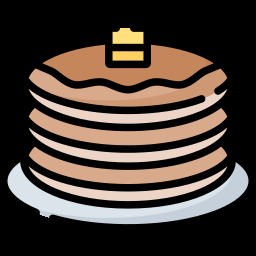

02.avif


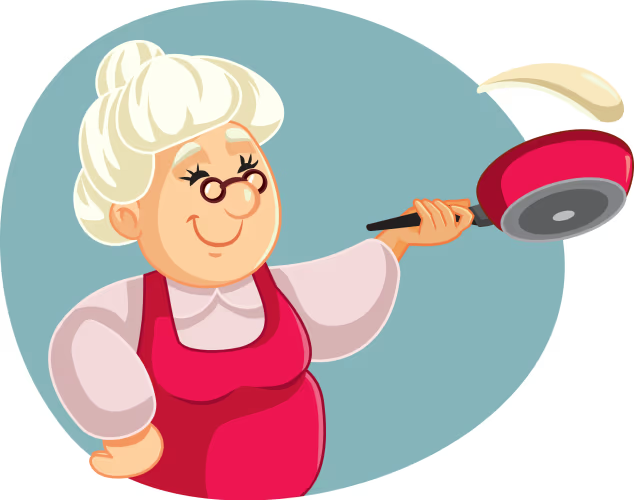

03.jpg


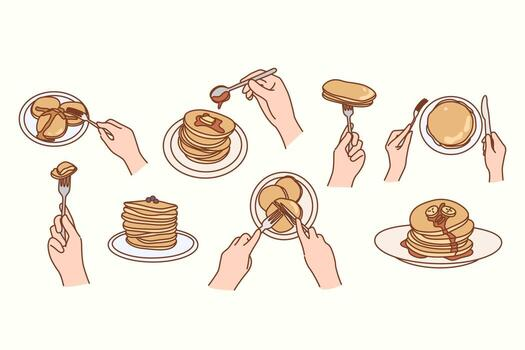

In [19]:
for path in image_paths:
    print(path)
    display(Image.open(path).convert("RGB"))

## 13. Helper: convert local image to base64 data URL

The Hugging Face chat-completions interface accepts image inputs as URLs or base64 data URLs.

In [12]:
def image_to_data_url(path: str):
    suffix = Path(path).suffix.lower().replace(".", "")
    mime = "jpeg" if suffix in ["jpg", "jpeg"] else suffix
    with open(path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")
    return f"data:image/{mime};base64,{encoded}"

As we are working on the topic of ICONS, it is not only about aesthetics but also about meaning:

The icon represents: [action or concept]

Expected user interpretation:
[short description]

In [13]:
ICON_MEANING = """
The icon represents: making pancake.

Users should understand that the action makes pancake.
"""

## 14. Prompt templates

These prompts make the system behave more like a **design critic** than a generic image captioner.

In [14]:
CRITIQUE_TEMPLATE = '''
You are a demanding but constructive icon design studio critic.

ICON INTENDED MEANING
{icon_meaning}

Use the design context below when relevant.

DESIGN CONTEXT
{design_context}

Analyze whether the icon clearly communicates the intended meaning.

Focus on:
- clarity of the intended meaning
- likelihood that users interpret the icon correctly
- legibility at small size
- silhouette distinctiveness
- visual complexity
- concreteness versus abstraction
- perceived aesthetics
- balance of positive and negative space
- consistency of stroke, geometry, and spacing
- communicative precision
- coherence of the icon design language

Return your answer in this exact structure:

Meaning clarity:
<Does the icon communicate the intended meaning?>

Possible misinterpretations:
- ...
- ...

Overall impression:
<2 to 4 sentences>

Strengths:
- ...
- ...
- ...

Weaknesses:
- ...
- ...
- ...

Design scorecard:
- Meaning clarity: X/10
- Legibility: X/10
- Aesthetic appeal: X/10
- Complexity control: X/10
- Concreteness / abstraction: X/10
- System coherence: X/10

Next design moves:
- ...
- ...
- ...

Be concrete and avoid generic praise.
'''.strip()


COMPARISON_TEMPLATE = '''
You are reviewing two iterations of an icon design.

ICON INTENDED MEANING
{icon_meaning}

Use the design context below when relevant.

DESIGN CONTEXT
{design_context}

The first image is the earlier version.
The second image is the newer version.

Compare them as a design evolution.

Return your answer in this exact structure:

What improved:
- ...
- ...
- ...

What became weaker or less clear:
- ...
- ...
- ...

Design evolution:
<3 to 6 sentences>

Priority for the next iteration:
- ...
- ...
- ...

Be specific about legibility, visual complexity, abstraction, aesthetics, and communicative clarity.
'''.strip()

CONFUSION_TEST_TEMPLATE = '''
You are evaluating an icon as if you were a first-time user who has not been told its intended meaning.

Use the design context below when relevant.

DESIGN CONTEXT
{design_context}

Infer what the icon most likely means.

Return your answer in this exact structure:

Top 3 possible meanings:
1. ...
2. ...
3. ...

Best guess:
<1 short sentence>

Confidence in best guess:
<X/10>

Visual evidence used for the guess:
- ...
- ...
- ...

Potential sources of confusion:
- ...
- ...
- ...

Clarity assessment:
<2 to 4 sentences>

Do not assume the designer's intention. Base your answer only on the icon itself.
'''.strip()

MEANING_MATCH_TEMPLATE = '''
You are comparing an icon's predicted meaning with its intended meaning.

INTENDED MEANING
{icon_meaning}

MODEL-PREDICTED MEANING
{predicted_meaning}

ALTERNATIVE POSSIBLE MEANINGS
{alternative_meanings}

CLARITY ASSESSMENT
{clarity_assessment}

Return your answer in this exact structure:

Meaning match:
<good match / partial match / weak match>

Where the icon succeeds:
- ...
- ...
- ...

Where the icon fails or risks misunderstanding:
- ...
- ...
- ...

Recommendation:
<2 to 4 sentences explaining what should change to make the meaning clearer>
'''.strip()


FINAL_REVIEW_TEMPLATE = '''
You are a senior design tutor reviewing the progression of a student's icon design project.

ICON INTENDED MEANING
{icon_meaning}

Use the design context below when relevant.

DESIGN CONTEXT
{design_context}

INDIVIDUAL CRITIQUES
{individual_critiques}

VERSION COMPARISONS
{comparisons}

Write a final studio review in this exact structure:

Main direction of the project:
<short paragraph>

Most successful qualities:
- ...
- ...
- ...

Recurring issues:
- ...
- ...
- ...

Design evolution timeline:
- Version 1: ...
- Version 2: ...
- Version 3: ...
- Continue as needed

How well does the project control aesthetics, complexity, and concreteness?
<short paragraph>

Is the project converging toward a coherent icon language?
<short paragraph>

Recommended next steps:
- ...
- ...
- ...

Overall studio scorecard:
- Aesthetic quality: X/10
- Complexity control: X/10
- Concreteness control: X/10
- Meaning clarity: X/10
- System coherence: X/10
- Iteration quality: X/10
'''.strip()

## 15. Define a helper to call the API with one or more images

In [15]:
def call_vlm(messages, model_id=MODEL_ID, max_tokens=900, temperature=0.4):
    response = client.chat.completions.create(
        model=model_id,
        messages=messages,
        max_tokens=max_tokens,
        temperature=temperature,
    )
    return response.choices[0].message.content

## 16. Critique each sketch with retrieved pdf context

For each sketch, the notebook first retrieves relevant passages from the uploaded book, then sends the sketch plus those passages to the hosted vision model.

In [20]:
def build_design_query_for_single_sketch(filename: str):
    return f'''
    I am trying to make an icon which should say: Making pancake.
    Icon design theory about aesthetics, visual complexity, concreteness, icon comprehension, legibility, and consistency in icon systems.
    Filename: {filename}
    '''.strip()

individual_results = []

for path in image_paths:
    retrieved = retrieve_design_context(build_design_query_for_single_sketch(path), k=3)
    design_context = "\n\n---\n\n".join(
        [f"[Chunk {r['chunk_id']} | score={r['score']:.3f}]\n{r['text']}" for r in retrieved]
    )

    prompt = CRITIQUE_TEMPLATE.format(
    icon_meaning=ICON_MEANING,
    design_context=design_context
)
    image_data_url = image_to_data_url(path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_data_url}},
            ],
        }
    ]

    critique = call_vlm(messages)

    individual_results.append({
        "image": path,
        "retrieved": retrieved,
        "critique": critique
    })

    display(Markdown(f"## Critique — {path}\n\n{critique}"))

## Critique — 01.png

Meaning clarity:
The icon communicates the intended meaning — making pancakes — with moderate success. The stacked, circular shapes strongly suggest pancakes, and the small rectangular element at the top resembles a spatula or a batter ladle, which reinforces the cooking action. However, the visual abstraction is high enough that the icon might be misread as a stack of plates, a layered dessert, or even a pile of coins.

Possible misinterpretations:
- Stack of plates or dinnerware
- Layered dessert (e.g., cake or crepes)
- Pile of coins or currency
- Generic “food” or “breakfast” symbol without specific action context
- Could be confused with a “pancake” icon that includes a frying pan or griddle

Overall impression:
The icon is visually clean and minimalist, with a pleasing color gradient and balanced silhouette. However, its abstraction prevents it from being immediately recognizable as an action icon — it looks more like a static object than a dynamic process. The lack of a cooking utensil or pan makes the “making” aspect ambiguous.

Strengths:
- Clean, simple silhouette with good negative space balance
- Color gradient adds visual interest without clutter
- Conveys “stacked food” effectively, which is a strong visual anchor
- Geometric consistency and uniform stroke weight

Weaknesses:
- Lacks key visual cues for “cooking” (e.g., pan, spatula, flame)
- Too abstract to clearly communicate “action” — users may interpret it as a result, not a process
- No clear visual metaphor for “making” — the top element is ambiguous
- Could be confused with other food-related icons due to high concreteness without sufficient abstraction

Design scorecard:
- Meaning clarity: 6/10
- Legibility: 8/10
- Aesthetic appeal: 8/10
- Complexity control: 9/10
- Concreteness / abstraction: 5/10
- System coherence: 7/10

Next design moves:
- Add a small frying pan or spatula element at the base or top to clarify the cooking action
- Consider adding a subtle flame or steam effect to reinforce “making”
- Use a more iconic, recognizable shape for the top element (e.g., a ladle or spatula handle)
- Test with users to confirm if the current top element is ambiguous — if so, replace it with a clearer symbol
- Consider a slight tilt or motion line to imply the action of flipping or pouring

## Critique — 02.avif

Meaning clarity:
The icon communicates the intended meaning — making pancakes — with high clarity. The visual of a person flipping a pancake in a pan is a direct, culturally recognized metaphor for the action.

Possible misinterpretations:
- Users might interpret the icon as representing a chef or general cooking, rather than specifically pancake-making.
- The elderly woman’s appearance might lead some to associate the icon with nostalgia or a specific demographic, potentially diluting the universal action it represents.
- The pancake is shown as a single, thin disc, which might be misinterpreted as a crepe or a flatbread, though this is a minor semantic issue.

Overall impression:
This is a charming and immediately recognizable icon. The action of flipping a pancake is clear and universally understood, making it effective for its purpose. However, the inclusion of a specific character (an elderly woman) introduces unnecessary visual complexity and potential for misinterpretation, which detracts from its precision as a universal symbol.

Strengths:
- The action (flipping a pancake) is visually explicit and unambiguous.
- The character’s joyful expression adds positive emotional context, enhancing user engagement.
- The silhouette of the pan and pancake is distinct and easily recognizable even at small sizes.

Weaknesses:
- The character’s specific appearance (elderly, glasses, bun) introduces unnecessary abstraction and potential for misinterpretation.
- The icon is visually heavy and complex for a simple action, reducing its scalability and legibility in constrained UI environments.
- The design lacks system coherence — it’s a character-centric illustration rather than a minimalist, abstract symbol, which may not fit well in a modern icon set.

Design scorecard:
- Meaning clarity: 9/10
- Legibility: 7/10
- Aesthetic appeal: 8/10
- Complexity control: 5/10
- Concreteness / abstraction: 7/10
- System coherence: 6/10

Next design moves:
- Replace the character with a simplified, abstracted figure (e.g., a generic hand or silhouette) to focus attention on the core action.
- Use a more minimalist pancake shape — perhaps a simple circle or semi-circle — to reduce visual clutter.
- Ensure consistent stroke weight and spacing across all elements to improve system coherence.
- Consider a flat, icon-style design with a solid color palette to enhance legibility and scalability.

## Critique — 03.jpg

Meaning clarity:
No, the icon does not communicate the intended meaning. The icon set depicts the *consumption* of pancakes, not their *making*. The intended meaning is “making pancake,” which requires visual cues of cooking action (e.g., a pan, spatula, batter, heat source) — none of which are present. Instead, the icons show eating, flipping, and serving, which are post-production actions.

Possible misinterpretations:
- Users will interpret the icon as “eating pancakes” or “pancake consumption.”
- Users may think it represents “pancake preparation” only if they are already familiar with the context (e.g., a cooking app), but this is not guaranteed.
- The icon may be confused with “pancake delivery” or “pancake restaurant” due to the presence of plates and utensils.

Overall impression:
This icon set is visually appealing and stylistically consistent, but it fundamentally misrepresents the intended action. The user’s understanding is inverted — they see a meal, not a recipe. The design’s strength lies in its aesthetic and legibility, but its core communicative failure is severe and undermines its usability.

Strengths:
- High legibility and visual clarity at small size due to simple, clean lines and distinct silhouettes.
- Strong aesthetic appeal with a warm, hand-drawn, inviting style that fits food-related contexts.
- Consistent stroke weight, spacing, and geometry across all icons, creating a unified visual language.

Weaknesses:
- Complete failure in meaning clarity — the action depicted is consumption, not creation.
- High visual complexity for the intended meaning: multiple icons are needed to convey different stages of eating, which is inefficient and confusing.
- Low concreteness for the intended meaning: the icons are abstract representations of eating, not concrete representations of cooking.

Design scorecard:
- Meaning clarity: 2/10
- Legibility: 9/10
- Aesthetic appeal: 8/10
- Complexity control: 7/10
- Concreteness / abstraction: 3/10
- System coherence: 9/10

Next design moves:
- Replace the eating scenes with cooking scenes: show a hand holding a spatula over a frying pan, pouring batter, flipping a pancake, and adding syrup to a cooked pancake.
- Use a single, unified icon that combines key cooking elements (pan, spatula, batter) to clearly signal “making pancake.”
- Test the new icon set with users to validate meaning clarity before finalizing.

## 17. Compare consecutive versions

This step analyzes the **design evolution** from one sketch to the next.

In [21]:
def build_design_query_for_comparison(prev_name: str, curr_name: str):
    return f'''
    Compare two icons across design iterations.
    Icon design theory about aesthetics, visual complexity, concreteness, icon comprehension, legibility, and consistency in icon systems.
    Earlier version: {prev_name}
    Newer version: {curr_name}
    '''.strip()

comparison_results = []

for i in range(1, len(image_paths)):
    prev_path = image_paths[i - 1]
    curr_path = image_paths[i]

    retrieved = retrieve_design_context(build_design_query_for_comparison(prev_path, curr_path), k=3)
    design_context = "\n\n---\n\n".join(
        [f"[Chunk {r['chunk_id']} | score={r['score']:.3f}]\n{r['text']}" for r in retrieved]
    )

    prompt = COMPARISON_TEMPLATE.format(
        icon_meaning=ICON_MEANING,
        design_context=design_context)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_to_data_url(prev_path)}},
                {"type": "image_url", "image_url": {"url": image_to_data_url(curr_path)}},
            ],
        }
    ]

    comparison = call_vlm(messages)

    comparison_results.append({
        "pair": f"{prev_path} -> {curr_path}",
        "retrieved": retrieved,
        "comparison": comparison
    })

    display(Markdown(f"## Comparison — {prev_path} → {curr_path}\n\n{comparison}"))

## Comparison — 01.png → 02.avif

What improved:
- Communicative clarity: The newer version explicitly shows the action (flipping a pancake) and the tool (pan), making the "making pancake" meaning unambiguous and intuitive.
- Visual concreteness: The newer icon uses a familiar, concrete representation of a person and a pan, which aligns with the design principle of using ordinary objects to convey meaning (Chunk 17).
- Aesthetics: The newer version is more visually appealing with its colorful, friendly character and dynamic pose, which enhances user engagement and perception (Chunk 48).

What became weaker or less clear:
- Legibility: The newer icon is significantly more complex and detailed, which may reduce legibility, especially at smaller sizes or for users with visual impairments.
- Visual complexity: The addition of a character, glasses, hair bun, and background circle increases visual clutter, potentially overwhelming users and detracting from the core message.
- Abstraction: The newer icon is more abstract in its representation of the action (a person flipping a pancake) rather than directly showing the pancake itself, which may be less direct than the earlier version.

Design evolution:
The design evolved from a minimalist, abstract representation of stacked pancakes to a more concrete, narrative-driven illustration featuring a character performing the action. This shift prioritizes communicative clarity and user intuition over simplicity, aligning with the principle of using familiar forms (Chunk 17). However, this comes at the cost of increased visual complexity and reduced legibility, which may impact usability in constrained contexts.

Priority for the next iteration:
- Reduce visual complexity: Simplify the character and background to maintain focus on the action and tool.
- Improve legibility: Ensure the icon remains recognizable and clear at small sizes.
- Balance abstraction: Consider a hybrid approach that retains the action (flipping) but uses a more simplified, less cluttered character or tool representation.

## Comparison — 02.avif → 03.jpg

What improved:
- The newer version uses a more abstract and minimalist style, reducing visual clutter and focusing on the core action of eating pancakes, which enhances communicative clarity for the intended meaning.
- The newer version employs a consistent, clean line-art aesthetic across all icons, improving visual legibility and creating a unified, modern look.
- The newer version avoids character depiction entirely, shifting from a concrete representation (the woman) to a more abstract depiction of the food and its consumption, which aligns with the design principle of concreteness manipulation.

What became weaker or less clear:
- The newer version’s abstraction may obscure the specific action of “making” pancakes, as it focuses on eating rather than cooking, potentially misaligning with the intended meaning.
- The newer version’s minimalist style, while clean, may lack the visual richness or emotional cue of the older version, which could reduce aesthetic appeal for some users.
- The newer version’s multiple icons, while showing different actions, may dilute the singular focus of the icon set, making it less immediately clear which specific action is being represented.

Design evolution:
The design evolved from a concrete, character-based illustration of a woman making pancakes to a minimalist, abstract set of icons depicting various pancake-eating actions. This shift prioritizes visual clarity and aesthetic consistency over narrative or character representation. However, the evolution risks losing the core meaning of “making” pancakes in favor of “eating” pancakes, which may confuse users expecting a cooking action.

Priority for the next iteration:
- Reintroduce or clarify the cooking action (e.g., flipping, pouring batter) to directly communicate “making” pancakes, balancing abstraction with functional clarity.
- Maintain the minimalist aesthetic but ensure the core action is visually dominant and unambiguous.
- Consider a single, unified icon that combines the abstract eating actions with a clear cooking element (like a pan or batter) to preserve both aesthetic simplicity and communicative accuracy.

## 18. confusion test


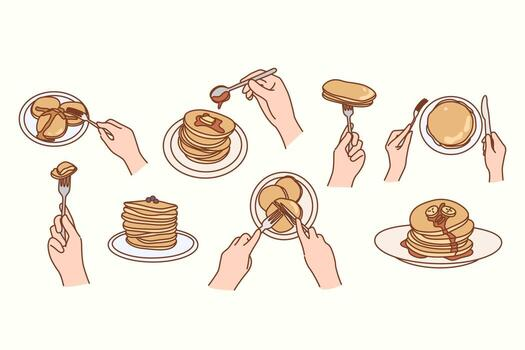

# Confusion Test

Top 3 possible meanings:
1. Eating pancakes
2. Breakfast food
3. Cooking or serving pancakes

Best guess:
A set of illustrations showing different ways to eat or prepare pancakes.

Confidence in best guess:
9/10

Visual evidence used for the guess:
- All images depict pancakes, a common breakfast food.
- Hands are shown holding forks, knives, or spoons, indicating eating or serving actions.
- Various presentations are shown: stacked, single, with syrup, being cut, etc.

Potential sources of confusion:
- The icon set is not a single symbol but a collection, which might be mistaken for a menu or a sequence.
- The style is illustrative and not symbolic, so it might be misinterpreted as a generic food icon rather than a specific dish.
- The presence of syrup and utensils might lead to confusion with other breakfast items like waffles or eggs.

Clarity assessment:
The icon set is clear and unambiguous in its subject matter — it consistently represents pancakes in various states of consumption. The illustrations are simple and recognizable, making the meaning intuitive for most users. However, because it’s a collection rather than a single symbol, it may not convey a specific action or object as efficiently as a single icon would.

In [22]:
retrieved = retrieve_design_context(
    "Icon design theory about aesthetics, visual complexity, concreteness, legibility, and icon comprehension.",
    k=4
)

design_context = "\n\n---\n\n".join(
    [f"[Chunk {r['chunk_id']} | score={r['score']:.3f}]\n{r['text']}" for r in retrieved]
)

confusion_prompt = CONFUSION_TEST_TEMPLATE.format(
    design_context=design_context
)

test_image = image_paths[-1]
display(Image.open(test_image).convert("RGB"))

messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": confusion_prompt},
            {"type": "image_url", "image_url": {"url": image_to_data_url(test_image)}},
        ],
    }
]

confusion_result = call_vlm(messages, max_tokens=800, temperature=0.3)
display(Markdown(f"# Confusion Test\n\n{confusion_result}"))

In [ ]:
meaning_match_prompt = MEANING_MATCH_TEMPLATE.format(
    icon_meaning=ICON_MEANING,
    predicted_meaning=confusion_result,
    alternative_meanings="See confusion test output above.",
    clarity_assessment="See confusion test output above."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": meaning_match_prompt}
        ],
    }
]

meaning_match_result = call_vlm(messages, max_tokens=500, temperature=0.2)
display(Markdown(f"# Meaning Match Review\n\n{meaning_match_result}"))

# Meaning Match Review

Meaning match:
partial match

Where the icon succeeds:
- The visual elements (hands, utensils, syrup, plates) consistently suggest consumption rather than preparation, aligning with the “eating pancakes” interpretation.
- The repeated use of syrup and serving context reinforces the idea of a meal being enjoyed, which supports the best guess.
- The stylized design, while minimalist, avoids introducing misleading symbols and keeps the focus on the act of eating.

Where the icon fails or risks misunderstanding:
- The presence of hands holding pancakes mid-air could be misinterpreted as flipping or cooking, especially without clear context of utensils or stove.
- The lack of explicit cooking tools (like spatulas, pans, or batter) risks conflating the action with preparation rather than consumption.
- The icon’s ambiguity around whether it’s a single pancake or stack may dilute the clarity of the intended meaning.

Recommendation:
To better align with the intended meaning of “making pancakes,” the icon should include visual cues of cooking—such as a frying pan, spatula, or batter—rather than utensils associated with eating. Adding a small cooking-related element (e.g., a spatula flipping a pancake) would reduce confusion and more clearly signal the action of preparation. Alternatively, if the intent is to represent eating, the icon should remove any ambiguous cooking gestures and emphasize consumption more explicitly (e.g., a pancake being lifted with a fork, syrup drizzled, and a plate clearly visible).

## 18. Build a final studio review and evolution timeline

This turns all the earlier outputs into a single **studio review**.

In [ ]:
individual_text = "\n\n".join(
    [f"Icon iteration: {r['image']}\n{r['critique']}" for r in individual_results]
)

comparison_text = "\n\n".join(
    [f"Comparison: {r['pair']}\n{r['comparison']}" for r in comparison_results]
)

retrieved = retrieve_design_context(
    "Overall review of a student icon design project across iterations, the icon is supposed to mean making pancakes, focusing on icon aesthetics, visual complexity, concreteness, communicative clarity, and design consistency.",
    k=4
)

design_context = "\n\n---\n\n".join(
    [f"[Chunk {r['chunk_id']} | score={r['score']:.3f}]\n{r['text']}" for r in retrieved]
)

final_prompt = FINAL_REVIEW_TEMPLATE.format(
    icon_meaning=ICON_MEANING,
    design_context=design_context,
    individual_critiques=individual_text,
    comparisons=comparison_text
)

anchor_image = image_paths[-1]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": final_prompt},
            {"type": "image_url", "image_url": {"url": image_to_data_url(anchor_image)}},
        ],
    }
]

final_review = call_vlm(messages, max_tokens=1200, temperature=0.3)
display(Markdown(f"# Final Icon Studio Review\n\n{final_review}"))

# Final Icon Studio Review

Main direction of the project:
The project initially focused on abstract, minimalist representations of pancakes, gradually evolving toward more concrete, action-oriented illustrations that explicitly depict the process of making pancakes. The direction shifted from symbolic abstraction to literal representation, with a clear emphasis on conveying the “making” action through visual cues like spatulas, pans, and flipping motions. However, the final iteration inadvertently misaligned with the core meaning, depicting eating rather than making, which represents a critical conceptual misstep that must be corrected.

Most successful qualities:
- The early iterations demonstrated strong concreteness and legibility, using familiar shapes (stacked pancakes) that are instantly recognizable.
- The second iteration successfully communicated the intended meaning with high clarity by showing the action of flipping a pancake, which is a universally understood gesture.
- The final set showed strong system coherence and visual consistency in style, line weight, and color palette, creating a unified aesthetic language across multiple icons.

Recurring issues:
- Meaning clarity was consistently compromised in the final iteration due to a fundamental misalignment with the intended action — depicting eating instead of making.
- The project struggled with balancing concreteness and abstraction: early versions were too abstract to clearly signal the action, while later versions became overly specific and culturally biased (e.g., the elderly woman character).
- Aesthetic appeal was often neutral or low, relying on generic, flat designs that lacked visual interest or emotional engagement, despite the potential for more dynamic and appealing representations.

Design evolution timeline:
- Version 1: A minimalist, abstract icon of stacked pancakes with a small top element suggesting a spatula or ladle. Communicates the object well but lacks explicit action cues, leading to potential misinterpretation as plates or dessert.
- Version 2: A detailed, concrete illustration of a person flipping a pancake in a pan. Communicates the action clearly and effectively, but introduces unnecessary complexity and cultural specificity (character design) that reduces scalability and legibility.
- Version 3: A set of icons depicting the act of eating pancakes, not making them. While visually appealing and stylistically consistent, this fundamentally misrepresents the intended meaning, reversing the core concept of the project.

How well does the project control aesthetics, complexity, and concreteness?
The project demonstrates moderate control over complexity and concreteness, with early versions being minimalist and later versions becoming more detailed. However, aesthetics were consistently underdeveloped, relying on flat, generic designs that lacked visual appeal or emotional resonance. The project also failed to maintain consistent control over the core meaning — the final iteration’s misrepresentation of “eating” instead of “making” undermines all other design considerations.

Is the project converging toward a coherent icon language?
The project is not converging toward a coherent icon language. While the final set shows visual consistency in style and line work, it diverges from the intended meaning, creating a fundamental inconsistency. The evolution from abstract to concrete to misaligned concrete does not represent a coherent design strategy. A true convergence would require a unified, consistent visual language that correctly communicates “making pancakes” across all iterations.

Recommended next steps:
- Immediately correct the core meaning: replace all icons depicting eating with those depicting cooking (e.g., hands holding spatulas over pans, mixing bowls with batter).
- Simplify the character-driven approach: use generic figures or remove characters entirely to improve universality and legibility.
- Introduce subtle visual cues for cooking: add small flame icons, pan outlines, or spatula shapes to reinforce the “making” action without increasing complexity.
- Test revised icons with users to validate meaning clarity and aesthetic appeal before finalizing.

Overall studio scorecard:
- Aesthetic quality: 6/10
- Complexity control: 7/10
- Concreteness control: 6/10
- Meaning clarity: 5/10
- System coherence: 8/10
- Iteration quality: 7/10

## 19. Build a simple score table

This step stores the main outputs in a small dataframe.  
The notebook does not force strict JSON parsing, so the score extraction below is optional and approximate.

In [ ]:
summary_rows = []

for r in individual_results:
    summary_rows.append({
        "image": r["image"],
        "critique": r["critique"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,image,critique
0,01.png,Overall impression:\nThis icon proposes a styl...
1,02.avif,Overall impression:\nThis icon attempts to con...
2,03.jpg,Overall impression:\nThis icon set attempts to...


## 20. Save a report as Markdown

This gives you a reusable text report for studio review, archiving, or discussion with students.

In [ ]:
report_path = "design_critic_agent_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("# Design Critic Agent Report\n\n")

    f.write("## Individual Critiques\n\n")
    for r in individual_results:
        f.write(f"### {r['image']}\n\n")
        f.write(r["critique"] + "\n\n")

    f.write("## Version Comparisons\n\n")
    for r in comparison_results:
        f.write(f"### {r['pair']}\n\n")
        f.write(r["comparison"] + "\n\n")

    f.write("## Final Studio Review\n\n")
    f.write(final_review + "\n")

print("Saved:", report_path)

Saved: design_critic_agent_report.md


## 21. Download the final report

In [ ]:
files.download("design_critic_agent_report.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

- The **Hugging Face route is limited**, so keep image counts small when testing, you're using my credits
- This notebook uses **retrieval from your uploaded pdf**, so critiques are grounded in this design references.
- If the selected model is not available for your account or route, change `MODEL_ID` to another supported image-text model.
- For best results, name your sketches in order:
  - `01.png`
  - `02.png`
  - `03.png`

This setup is a practical starting point for understanding how to create an Agent.

## 22. Run it on your laptop

**1. Download the python script**

Open a terminal and activate the conda environement we created last week:

```
conda activate yolo-env1
```

```
pip install PyPDF
pip install sentence-transformers
```

Create a folder to store the python file

| Windows | Mac / Linux |
|--------|-------------|
| `mkdir %USERPROFILE%\Documents\EvolutionAI\Agent` | `mkdir -p ~/Documents/EvolutionAI/Agent` |

Go to the directory just created

| Windows | Mac / Linux |
|--------|-------------|
| `cd %USERPROFILE%\Documents\EvolutionAI\Agent` | `cd ~/Documents/EvolutionAI/Agent` |

Download the python code

With UI:

```
curl -o app_icon_design_critic.py https://raw.githubusercontent.com/ddribes/Evolution_of_AI/main/python/llmAndAgent/app_icon_design_critic.py
```



Now Run it:

```
python app_icon_design_critic.py
```